<link rel="stylesheet" href="notebook_theme.css">

<div class="na-section-card">
  <div style="display:flex;flex-wrap:wrap;gap:0.55rem;margin-bottom:1rem;">
    <span class="na-kicker">Nebius Academy Inspired</span>
    <span class="na-kicker" style="background:rgba(231,245,253,0.8);border-color:rgba(45,134,241,0.16);">AI Performance Engineering</span>
  </div>
  <h1 style="margin-top:0;">Optimization in PyTorch</h1>
  <p style="font-size:1.12rem;margin:0;color:rgba(20, 7, 15, 0.75);max-width:900px;">
    Gradient Descent, SGD, Numerical Stability, and L1 Regularization.
    A cleaner visual treatment for the assignment notebook using Nebius Academy palette, spacing, and card-based presentation.
  </p>
</div>

**General guidelines for this (and future) hometasks**

* **Do not delete the task formulations**
* Many hometasks will be like "implement something, then perform experiments, then write your conclusions". We're sure many of you will delegate the first and the second step to coding agents, but please do at least the final stage yourself :)
* The plots should be meaningful: a plot must have a name, every curve or point cloud on a plot must be labeled
* Plots supporting comparison should actually enable it. For example, if you compare training loss curves of two models, they should be either on the same plot or side by side, with the same axis scales
* It goes without saying that the takeaways should actually follow from the evidence ;)

**Learning goals of this hometask**

By completing this assignment, you will:
1. Understand preprocessing design choices (tokenization provided, fixed vocabulary).
2. Implement and train Logistic Regression manually in PyTorch using SGD.
3. Explain why numerical stability matters in softmax and log-loss.
4. Understand how optimization parameters like learning rate and batch size affect training.
5. Understand the effect of L1 regularization and why it encourages sparsity.
6. Understanding how an optimization algorithm behaves when the loss function has different shapes.


**The dataset and the task**

For this assignment, we will use the SST-2 dataset (  [The Stanford Sentiment Treebank](https://huggingface.co/datasets/stanfordnlp/sst2).), a binary sentiment classification dataset in which each sentence is labeled as either negative or positive.

We will use linear models for classification, which means that we need a fixed number of numerical features to describe each sentence. For that, we'll perform:

* **Preprocessing** - to make the data a little more well-behaved
* **Tokenization** - splitting the sentences into atomic units - in this case, words
* **Feature creation** - turning bags of words into numerical features - word frequencies. We keep only 10,000 most frequent words, because we can only work with fixed-length feature vectors. You'll see that more "serious" models, such as LLMs, use fixed-length vocabularies too, though we'll learn how to do it without discarding information (by using sub-word and bit-wise tokenization).

Tokenization and preprocessing are already implemented for you in this task, but we want you to understand the design choices behind the them, so please check the description below (in the hidden cells).

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [56]:
import re
import random
from collections import Counter
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("Torch version:", torch.__version__)
print("Seed fixed to 42")

Torch version: 2.11.0
Seed fixed to 42


In [57]:
# Uncomment if needed in a fresh environment
!pip install datasets -q
!pip install -q ipywidgets widgetsnbextension jupyterlab_widgets

from datasets import load_dataset

sst2 = load_dataset("SetFit/sst2")
data_train = sst2["train"]
data_val = sst2["validation"]

def clean_text(text: str) -> str:
    text = text.lower()
    text = text.replace("-", " ")
    text = re.sub(r"[^a-zA-Z0-9\s.,!?]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data_train = data_train.map(lambda x: {"clean_text": clean_text(x["text"])})
data_val = data_val.map(lambda x: {"clean_text": clean_text(x["text"])})

print("Train size:", len(data_train))
print("Validation size:", len(data_val))

Repo card metadata block was not found. Setting CardData to empty.


Train size: 6920
Validation size: 872


**Text Cleaning**

Before converting text into a numerical representation (e.g., Bag-of-Words), it is important to apply text cleaning.

The goal of this step is to reduce noise and ensure that similar pieces of text are represented consistently.

We use the following cleaning function:

In [58]:
print("Sample cleaned examples:\n")
for _ in range(5):
    r = random.randint(0, len(data_train) - 1)
    print(f"label={data_train[r]['label']} | {data_train[r]['clean_text']}")

Sample cleaned examples:

label=1 | the extent to which it succeeds is impressive .
label=1 | remarkable for its excellent storytelling , its economical , compressed characterisations and for its profound humanity , it s an adventure story and history lesson all in one .
label=1 | the unexpected thing is that its dying , in this shower of black and white psychedelia , is quite beautiful .
label=0 | matrix style massacres erupt throughout ... but the movie has a tougher time balancing its violence with kafka inspired philosophy .
label=1 | the closest thing to the experience of space travel


In [59]:
train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

print("Training label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / len(data_train):.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / len(data_train):.2%})")

print("\nValidation label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / len(data_val):.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / len(data_val):.2%})")

Training label distribution:
Negative (0): 3310 (47.83%)
Positive (1): 3610 (52.17%)

Validation label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standart practice.


In [60]:
def tokenize(text):
    return text.split()

def build_vocabulary(data, top_k=10000):
    token_counter = Counter()
    for text in data["clean_text"]:
        token_counter.update(tokenize(text))
    most_common = token_counter.most_common(top_k)
    return {word: i for i, (word, _) in enumerate(most_common)}

def convert_text_to_vec(text, vocab):
    vec = np.zeros(len(vocab), dtype=np.int32)
    for token in tokenize(text):
        if token in vocab:
            vec[vocab[token]] += 1
    return vec

def dataset_to_vec(data, vocab):
    return np.array([convert_text_to_vec(text, vocab) for text in data["clean_text"]])

vocab = build_vocabulary(data_train, top_k=10000)

X_train = dataset_to_vec(data_train, vocab)
y_train = np.array(data_train["label"], dtype=np.float32)

X_val = dataset_to_vec(data_val, vocab)
y_val = np.array(data_val["label"], dtype=np.float32)

print("Vocabulary size:", len(vocab))
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

Vocabulary size: 10000
X_train shape: (6920, 10000)
X_val shape: (872, 10000)


**Our training data for the task 1 will be:**

In [61]:
example = X_train[0]
nz = np.where(example > 0)[0]

print("Example tokens:", tokenize(data_train["clean_text"][0]))
print("Number of tokens:", len(tokenize(data_train["clean_text"][0])))
print("Number of non-zero entries:", len(nz))
print("\nFirst few non-zero entries:")
for idx in nz[:20]:
    print(f"index={idx}, count={example[idx]}")

Example tokens: ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're', 'imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']
Number of tokens: 18
Number of non-zero entries: 16

First few non-zero entries:
index=1, count=1
index=2, count=1
index=3, count=1
index=4, count=3
index=5, count=1
index=66, count=1
index=118, count=1
index=119, count=1
index=361, count=1
index=554, count=1
index=646, count=1
index=1317, count=1
index=1822, count=1
index=4926, count=1
index=7197, count=1
index=7198, count=1


### **Part 1 - Implement SGD for Logistic Regression in PyTorch**

####**Task 1.1. - Implement Logistic Regression in PyTorch (2 points)**



In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [62]:
class LogisticRegression(nn.Module):
    def __init__(self, n_features, init="zeros"):
        super().__init__()

        if init == "zeros":
            w = torch.zeros((n_features, 1), dtype=torch.float32)
        elif init == "random":
            w = 0.01 * torch.randn((n_features, 1), dtype=torch.float32)
        elif isinstance(init, torch.Tensor):
            w = init.clone().detach().float().view(n_features, 1)
        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")

        self.w = nn.Parameter(w)
        self.b = nn.Parameter(torch.zeros(1, dtype=torch.float32))

    def forward(self, x):
        logits = x @ self.w + self.b
        probs = torch.sigmoid(logits)
        return probs

    def predict(self, x):
        probs = self.forward(x)
        preds = (probs >= 0.5).float()
        return preds

####**Task 1.2 - Train Logistic Regression with SGD Using Your Previous Implementations (1 point)**

In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use your LogisticRegression class from Task 1.1.

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revised



In [63]:
def binary_cross_entropy_loss(y_pred, y_true):
    epsilon = 1e-15
    y_pred = torch.clamp(y_pred, epsilon, 1.0 - epsilon)
    loss = -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    return loss.mean()

In [64]:
def accuracy_score_torch(y_true, y_pred):
    return (y_true == y_pred).float().mean().item()

def f1_score_torch(y_true, y_pred):
    y_true = y_true.float()
    y_pred = y_pred.float()

    tp = ((y_true == 1) & (y_pred == 1)).sum().item()
    fp = ((y_true == 0) & (y_pred == 1)).sum().item()
    fn = ((y_true == 1) & (y_pred == 0)).sum().item()

    precision = tp / (tp + fp + 1e-15)
    recall = tp / (tp + fn + 1e-15)
    return 2 * precision * recall / (precision + recall + 1e-15)

In [65]:
def sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=0.01,
    epochs=20,
    batch_size=100,
    init="zeros",
    penalty="none",          # 'none', 'l1', 'l2'
    reg_lambda=0.0,
    metric="accuracy",
    print_metrics=False
):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    n_samples, n_features = X_train_tensor.shape

    model = LogisticRegression(n_features=n_features, init=init)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    history = []
    epoch_log = []

    for epoch in range(epochs):
        perm = torch.randperm(n_samples)
        X_train_epoch = X_train_tensor[perm]
        y_train_epoch = y_train_tensor[perm]

        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            X_batch = X_train_epoch[start:end]
            y_batch = y_train_epoch[start:end]

            y_pred = model(X_batch)
            data_loss = binary_cross_entropy_loss(y_pred, y_batch)

            if penalty == "l1":
                reg_term = reg_lambda * torch.abs(model.w).sum()
            elif penalty == "l2":
                reg_term = reg_lambda * (model.w ** 2).sum()
            else:
                reg_term = 0.0

            loss = data_loss + reg_term

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            history.append({
                "epoch": epoch,
                "batch_start": start,
                "w": model.w.detach().clone(),
                "b": model.b.detach().clone(),
            })

        with torch.no_grad():
            y_pred_train = model(X_train_tensor)
            y_pred_val = model(X_val_tensor)

            train_loss = binary_cross_entropy_loss(y_pred_train, y_train_tensor)
            val_loss = binary_cross_entropy_loss(y_pred_val, y_val_tensor)

            y_hat_train = (y_pred_train >= 0.5).float()
            y_hat_val = (y_pred_val >= 0.5).float()

            if metric == "f1":
                train_metric = f1_score_torch(y_train_tensor, y_hat_train)
                val_metric = f1_score_torch(y_val_tensor, y_hat_val)
            else:
                train_metric = accuracy_score_torch(y_train_tensor, y_hat_train)
                val_metric = accuracy_score_torch(y_val_tensor, y_hat_val)

        epoch_log.append({
            "epoch": epoch + 1,
            "train_loss": train_loss.item(),
            "val_loss": val_loss.item(),
            "train_metric": train_metric,
            "val_metric": val_metric,
        })

        if print_metrics:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

    return (
        model.w.detach().cpu().numpy(),
        model.b.detach().cpu().numpy(),
        history,
        epoch_log
    )

** ANSWER ** 

on the QUESTION #4 above "Briefly explain why this metric is suitable for this task":
Used accuracy here because it is the most direct metric for binary classification: it shows what fraction of predictions are correct. It is 
suitable for this because it is easy to interpret and useful for comparing optimization behavior across epochs. 
For imbalanced classes, F1-score would be more informative since it combines precision and recall.

In [66]:
w, b, history, epoch_log = sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=0.1,
    epochs=10,
    batch_size=100,
    init="random",
    penalty="none",
    reg_lambda=0.0,
    metric="accuracy",
    print_metrics=True
)

Epoch 1/10 | Train Loss: 0.6665 | Val Loss: 0.6641 | Train accuracy: 0.6279 | Val accuracy: 0.6433
Epoch 2/10 | Train Loss: 0.6510 | Val Loss: 0.6484 | Train accuracy: 0.6604 | Val accuracy: 0.6732
Epoch 3/10 | Train Loss: 0.6385 | Val Loss: 0.6361 | Train accuracy: 0.6707 | Val accuracy: 0.6869
Epoch 4/10 | Train Loss: 0.6278 | Val Loss: 0.6268 | Train accuracy: 0.6900 | Val accuracy: 0.6984
Epoch 5/10 | Train Loss: 0.6183 | Val Loss: 0.6184 | Train accuracy: 0.6936 | Val accuracy: 0.7041
Epoch 6/10 | Train Loss: 0.6110 | Val Loss: 0.6124 | Train accuracy: 0.7051 | Val accuracy: 0.7133
Epoch 7/10 | Train Loss: 0.6037 | Val Loss: 0.6066 | Train accuracy: 0.7150 | Val accuracy: 0.7248
Epoch 8/10 | Train Loss: 0.5962 | Val Loss: 0.6008 | Train accuracy: 0.7120 | Val accuracy: 0.7064
Epoch 9/10 | Train Loss: 0.5889 | Val Loss: 0.5948 | Train accuracy: 0.7348 | Val accuracy: 0.7339
Epoch 10/10 | Train Loss: 0.5823 | Val Loss: 0.5895 | Train accuracy: 0.7344 | Val accuracy: 0.7282


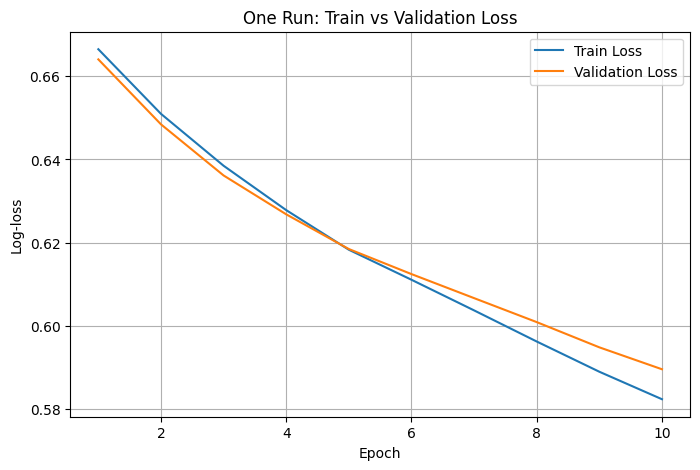

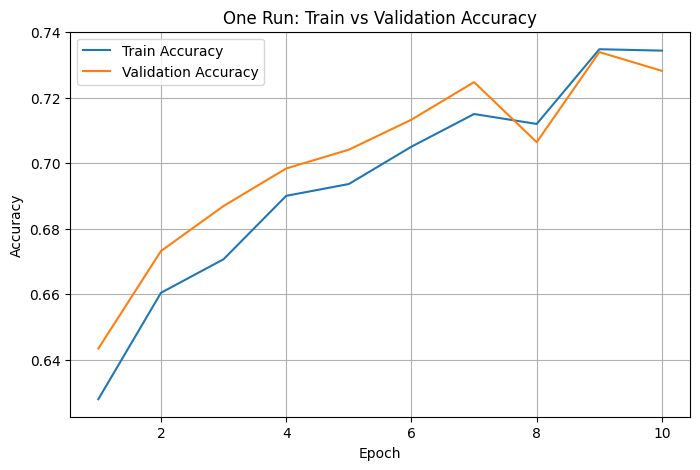

In [67]:
# Visualisation

epochs_axis = [row["epoch"] for row in epoch_log]
train_losses = [row["train_loss"] for row in epoch_log]
val_losses = [row["val_loss"] for row in epoch_log]
train_accs = [row["train_metric"] for row in epoch_log]
val_accs = [row["val_metric"] for row in epoch_log]

plt.figure(figsize=(8, 5))
plt.plot(epochs_axis, train_losses, label="Train Loss")
plt.plot(epochs_axis, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Log-loss")
plt.title("One Run: Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_axis, train_accs, label="Train Accuracy")
plt.plot(epochs_axis, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("One Run: Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

####**Task 1.3 - Experiments (2 points)**




Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.


In [68]:
learning_rates = [0.01, 0.03, 0.1, 0.3, 1.0]
batch_sizes = [50, 100, 200]

results = []

for bs in batch_sizes:
    for lr in learning_rates:
        print(f"Running lr={lr}, batch_size={bs}")
        _, _, _, log = sgd_logistic_regression(
            X_train, y_train,
            X_val, y_val,
            lr=lr,
            epochs=10,
            batch_size=bs,
            init="random",
            penalty="none",
            reg_lambda=0.0,
            metric="accuracy",
            print_metrics=False
        )
        final = log[-1]
        results.append({
            "batch_size": bs,
            "lr": lr,
            "train_loss": final["train_loss"],
            "val_loss": final["val_loss"],
            "train_metric": final["train_metric"],
            "val_metric": final["val_metric"]
        })

Running lr=0.01, batch_size=50
Running lr=0.03, batch_size=50
Running lr=0.1, batch_size=50
Running lr=0.3, batch_size=50
Running lr=1.0, batch_size=50
Running lr=0.01, batch_size=100
Running lr=0.03, batch_size=100
Running lr=0.1, batch_size=100
Running lr=0.3, batch_size=100
Running lr=1.0, batch_size=100
Running lr=0.01, batch_size=200
Running lr=0.03, batch_size=200
Running lr=0.1, batch_size=200
Running lr=0.3, batch_size=200
Running lr=1.0, batch_size=200


In [69]:
def result_matrix(results, row_values, col_values, value_key):
    mat = np.zeros((len(row_values), len(col_values)))
    for i, rv in enumerate(row_values):
        for j, cv in enumerate(col_values):
            row = [r for r in results if r["batch_size"] == rv and r["lr"] == cv][0]
            mat[i, j] = row[value_key]
    return mat

val_metric_mat = result_matrix(results, batch_sizes, learning_rates, "val_metric")
val_loss_mat = result_matrix(results, batch_sizes, learning_rates, "val_loss")
train_metric_mat = result_matrix(results, batch_sizes, learning_rates, "train_metric")
train_loss_mat = result_matrix(results, batch_sizes, learning_rates, "train_loss")

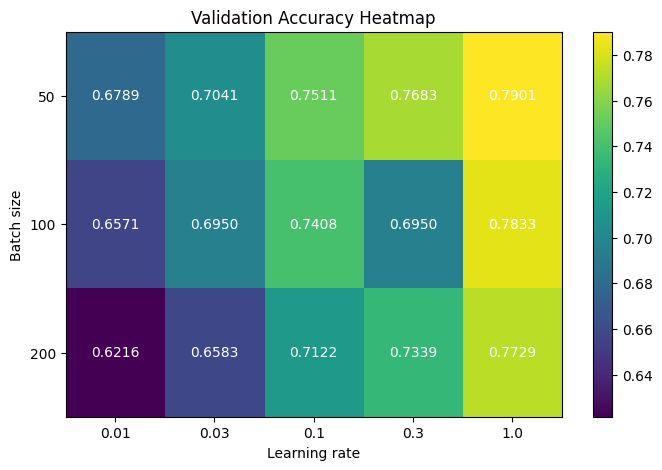

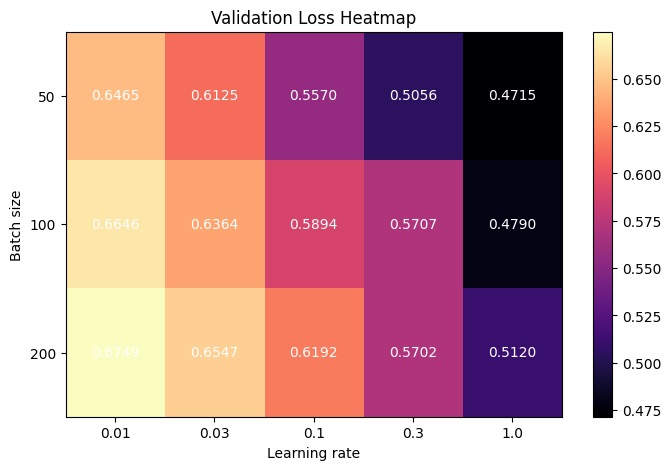

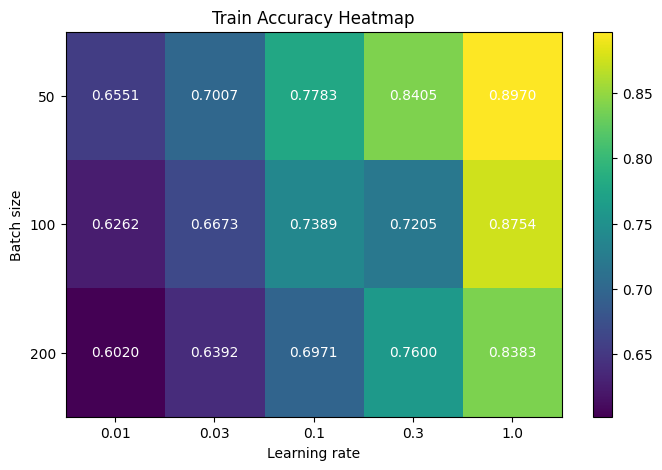

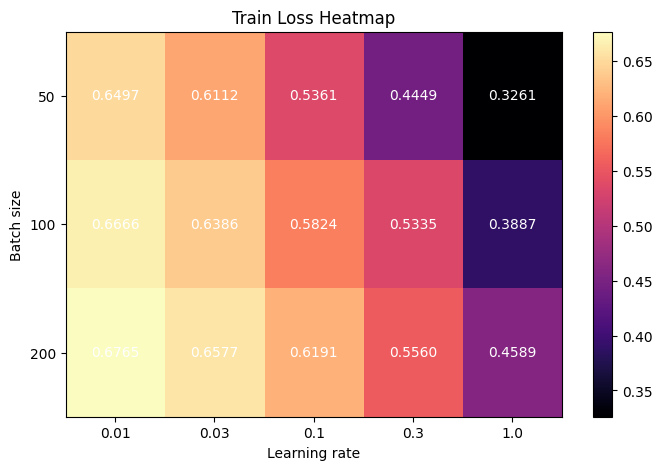

In [70]:
def plot_heatmap(matrix, x_labels, y_labels, title, cmap="viridis", fmt=".4f"):
    plt.figure(figsize=(8, 5))
    plt.imshow(matrix, aspect="auto", cmap=cmap)
    plt.colorbar()
    plt.xticks(range(len(x_labels)), x_labels)
    plt.yticks(range(len(y_labels)), y_labels)
    plt.xlabel("Learning rate")
    plt.ylabel("Batch size")
    plt.title(title)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(j, i, format(matrix[i, j], fmt), ha="center", va="center", color="white")

    plt.show()

plot_heatmap(val_metric_mat, learning_rates, batch_sizes, "Validation Accuracy Heatmap")
plot_heatmap(val_loss_mat, learning_rates, batch_sizes, "Validation Loss Heatmap", cmap="magma")
plot_heatmap(train_metric_mat, learning_rates, batch_sizes, "Train Accuracy Heatmap")
plot_heatmap(train_loss_mat, learning_rates, batch_sizes, "Train Loss Heatmap", cmap="magma")

** TASK: **
Explain how learning rate and batch size affect:
* convergence speed
* stability of training
* final performance

Support your explanation using the patterns observed in your heatmap.

** ANSWER: **
Train Accuracy and Train Loss show how well the model learns the training data. 
Validation Accuracy and Validation Loss show how well it generalizes to the data unknown during the training.

I observe that Learning Rate hyper parameter has the largest impact on training in this experiment.

* Convergence Speed: higher Learning Rates produced faster Convergence: with an increase of Learning Rate, Train/Validation Accuracy increased and Train/Validation Loss decreased faster. Very small Learning Rates converged slowly. Larger Batch Sizes converged a bit more slowly than smaller ones.
* Stability of the Training: Batch Size mainly affects it. Smaller batches make training noisier, and larger batches make updates smoother and more stable. In theory, too large Learning Rate can make training unstable, but in these heatmaps lr = 1.0 still stable.
* Final performance: the best Final Performance is with high Learning Rates. The best Validation Accuracy is at lr = 1.0, batch size = 200. The lowest Validation Loss is at lr = 1.0, batch size = 50.


####**Task 1.4 — L1 Regularization and Sparsity (2 points)**



In this task, you will extend your implementation from Task 1.3 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

In [71]:
def count_nonzero_weights(w, threshold=1e-7):
    return int(np.sum(np.abs(w) > threshold))

In [72]:
lambdas = [0, 1e-4, 1e-3, 1e-2, 1e-1]
l1_results = []

for init in ["zeros", "random"]:
    for lam in lambdas:
        print(f"Running init={init}, lambda={lam}")
        w, b, history, log = sgd_logistic_regression(
            X_train, y_train,
            X_val, y_val,
            lr=0.1,
            epochs=10,
            batch_size=100,
            init=init,
            penalty="l1",
            reg_lambda=lam,
            metric="accuracy",
            print_metrics=False
        )
        final = log[-1]
        l1_results.append({
            "init": init,
            "lambda": lam,
            "train_metric": final["train_metric"],
            "val_metric": final["val_metric"],
            "train_loss": final["train_loss"],
            "val_loss": final["val_loss"],
            "nonzero": count_nonzero_weights(w, threshold=1e-7),
            "w": w,
            "history": history,
        })

Running init=zeros, lambda=0
Running init=zeros, lambda=0.0001
Running init=zeros, lambda=0.001
Running init=zeros, lambda=0.01
Running init=zeros, lambda=0.1
Running init=random, lambda=0
Running init=random, lambda=0.0001
Running init=random, lambda=0.001
Running init=random, lambda=0.01
Running init=random, lambda=0.1


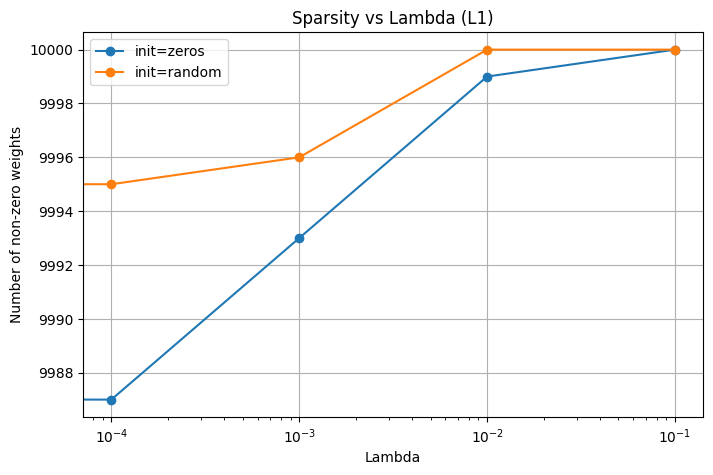

In [73]:
plt.figure(figsize=(8, 5))
for init in ["zeros", "random"]:
    xs = [r["lambda"] for r in l1_results if r["init"] == init]
    ys = [r["nonzero"] for r in l1_results if r["init"] == init]
    plt.plot(xs, ys, marker="o", label=f"init={init}")
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Number of non-zero weights")
plt.title("Sparsity vs Lambda (L1)")
plt.legend()
plt.grid(True)
plt.show()

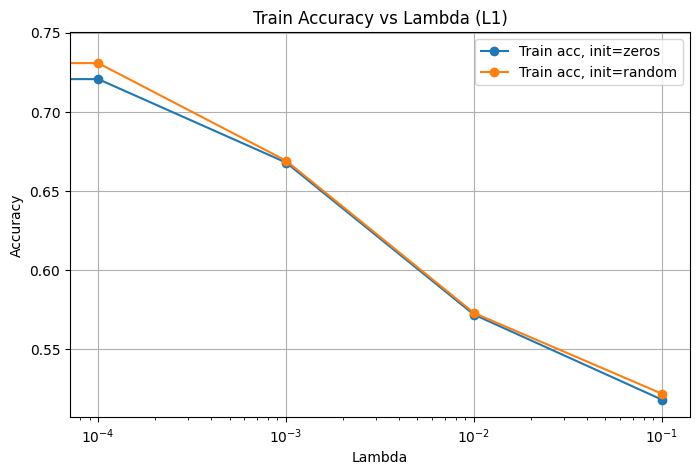

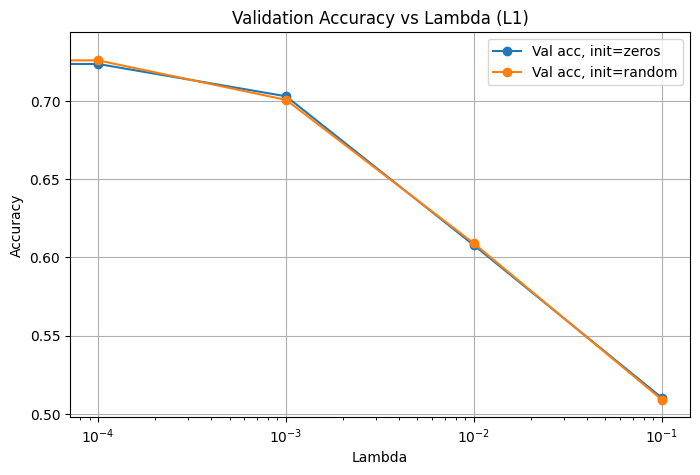

In [74]:
plt.figure(figsize=(8, 5))
for init in ["zeros", "random"]:
    xs = [r["lambda"] for r in l1_results if r["init"] == init]
    ys = [r["train_metric"] for r in l1_results if r["init"] == init]
    plt.plot(xs, ys, marker="o", label=f"Train acc, init={init}")
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Accuracy")
plt.title("Train Accuracy vs Lambda (L1)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
for init in ["zeros", "random"]:
    xs = [r["lambda"] for r in l1_results if r["init"] == init]
    ys = [r["val_metric"] for r in l1_results if r["init"] == init]
    plt.plot(xs, ys, marker="o", label=f"Val acc, init={init}")
plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Lambda (L1)")
plt.legend()
plt.grid(True)
plt.show()

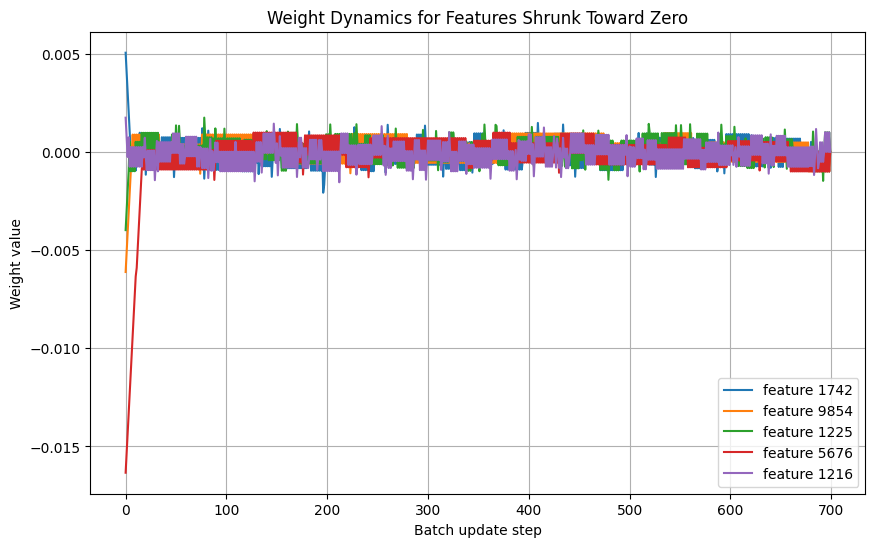

In [75]:
# Choose one representative run for visualizing near-eliminated weights
chosen = [r for r in l1_results if r["init"] == "random" and r["lambda"] == 1e-2][0]
final_w = chosen["w"].reshape(-1)

indices_sorted = np.argsort(np.abs(final_w))
tracked_features = indices_sorted[:5]

feature_trajectories = {idx: [] for idx in tracked_features}
for step in chosen["history"]:
    w_step = step["w"].cpu().numpy().reshape(-1)
    for idx in tracked_features:
        feature_trajectories[idx].append(w_step[idx])

plt.figure(figsize=(10, 6))
for idx in tracked_features:
    plt.plot(feature_trajectories[idx], label=f"feature {idx}")
plt.xlabel("Batch update step")
plt.ylabel("Weight value")
plt.title("Weight Dynamics for Features Shrunk Toward Zero")
plt.legend()
plt.grid(True)
plt.show()

TASK: A small paragraph summarizing my insights

ANSWER:

For Task 1.4, the comparison between zero initialization and random initialization shows only small differences: neither setup diverged or produced NaNs, their final train and validation accuracies stayed close, and the sparsity patterns were also similar, with random initialization being only slightly different at smaller values of $\lambda$. The main effect comes from the L1 penalty itself rather than from initialization. As $\lambda$ increases, more weights are pushed close to zero and the model becomes simpler, but this also reduces both training and validation accuracy, which indicates increasing underfitting at larger regularization strengths. The weight-dynamics plot supports this interpretation, because features that are not very useful are rapidly shrunk toward zero and then fluctuate only slightly around it due to minibatch noise. Overall, weak L1 regularization is acceptable in this experiment, while strong L1 makes the model too sparse and hurts performance.

### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (3 points)**


In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A — Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B — the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

In [76]:
def bowl(theta):
    x, y = theta[..., 0], theta[..., 1]
    return x**2 + 4 * y**2

def camel(theta):
    x, y = theta[..., 0], theta[..., 1]
    return (4 - 2.1 * x**2 + x**4 / 3) * x**2 + x * y + (-4 + 4 * y**2) * y**2

In [77]:
def plot_trajectories_contour(f, results, xlim=(-3, 3), ylim=(-2, 2), title="Optimization Trajectories"):
    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_values, y_values)

    grid = np.stack((X, Y), axis=-1)
    Z = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, np.log1p(np.abs(Z)), levels=30)

    for name, (trajectory, _) in results.items():
        traj = trajectory.detach().numpy()
        plt.plot(traj[:, 0], traj[:, 1], marker='o', markersize=2, label=name)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_values(results, title):
    plt.figure(figsize=(9, 5))
    for name, (_, values) in results.items():
        plt.plot(values, label=name)
    plt.xlabel("Iteration")
    plt.ylabel("Function value")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [78]:
class Optimizer:
    def __init__(self, lr):
        self.lr = lr

    def init_state(self, theta):
        return None

    def step(self, theta, grad, state, step_idx):
        raise NotImplementedError

    def optimize(self, f, theta0, n_steps=200):
        theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
        state = self.init_state(theta)

        trajectory = [theta.detach().clone()]
        values = [f(theta).item()]

        for step_idx in range(1, n_steps + 1):
            loss = f(theta)
            loss.backward()
            grad = theta.grad.detach().clone()

            with torch.no_grad():
                theta, state = self.step(theta, grad, state, step_idx)

            theta.grad.zero_()
            trajectory.append(theta.detach().clone())
            values.append(f(theta).item())

        return torch.stack(trajectory), values

class GradientDescentOptimizer(Optimizer):
    def step(self, theta, grad, state, step_idx):
        theta -= self.lr * grad
        return theta, state

class MomentumOptimizer(Optimizer):
    def __init__(self, lr, beta=0.9):
        super().__init__(lr)
        self.beta = beta

    def init_state(self, theta):
        return {"velocity": torch.zeros_like(theta)}

    def step(self, theta, grad, state, step_idx):
        state["velocity"] = self.beta * state["velocity"] + grad
        theta -= self.lr * state["velocity"]
        return theta, state

class AdaGradOptimizer(Optimizer):
    def __init__(self, lr, eps=1e-8):
        super().__init__(lr)
        self.eps = eps

    def init_state(self, theta):
        return {"grad_sq_sum": torch.zeros_like(theta)}

    def step(self, theta, grad, state, step_idx):
        state["grad_sq_sum"] += grad ** 2
        theta -= self.lr * grad / (torch.sqrt(state["grad_sq_sum"]) + self.eps)
        return theta, state

class AdamOptimizer(Optimizer):
    def __init__(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        super().__init__(lr)
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps

    def init_state(self, theta):
        return {
            "m": torch.zeros_like(theta),
            "v": torch.zeros_like(theta),
        }

    def step(self, theta, grad, state, step_idx):
        state["m"] = self.beta1 * state["m"] + (1 - self.beta1) * grad
        state["v"] = self.beta2 * state["v"] + (1 - self.beta2) * (grad ** 2)

        m_hat = state["m"] / (1 - self.beta1 ** step_idx)
        v_hat = state["v"] / (1 - self.beta2 ** step_idx)

        theta -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)
        return theta, state

def gradient_descent(f, theta0, lr=0.001, n_steps=200):
    optimizer = GradientDescentOptimizer(lr=lr)
    return optimizer.optimize(f, theta0, n_steps=n_steps)

def momentum(f, theta0, lr=0.001, beta=0.9, n_steps=200):
    optimizer = MomentumOptimizer(lr=lr, beta=beta)
    return optimizer.optimize(f, theta0, n_steps=n_steps)

def adagrad(f, theta0, lr=0.1, eps=1e-8, n_steps=200):
    optimizer = AdaGradOptimizer(lr=lr, eps=eps)
    return optimizer.optimize(f, theta0, n_steps=n_steps)

def adam(f, theta0, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=200):
    optimizer = AdamOptimizer(lr=lr, beta1=beta1, beta2=beta2, eps=eps)
    return optimizer.optimize(f, theta0, n_steps=n_steps)

In [79]:
theta0 = [-1.5, 1.5]

results_bowl = {
    "GD": gradient_descent(bowl, theta0, lr=0.05, n_steps=200),
    "Momentum": momentum(bowl, theta0, lr=0.03, beta=0.9, n_steps=200),
    "AdaGrad": adagrad(bowl, theta0, lr=0.3, n_steps=200),
    "Adam": adam(bowl, theta0, lr=0.1, n_steps=200),
}

results_camel = {
    "GD": gradient_descent(camel, theta0, lr=0.001, n_steps=500),
    "Momentum": momentum(camel, theta0, lr=0.001, beta=0.9, n_steps=500),
    "AdaGrad": adagrad(camel, theta0, lr=0.05, n_steps=500),
    "Adam": adam(camel, theta0, lr=0.02, n_steps=500),
}

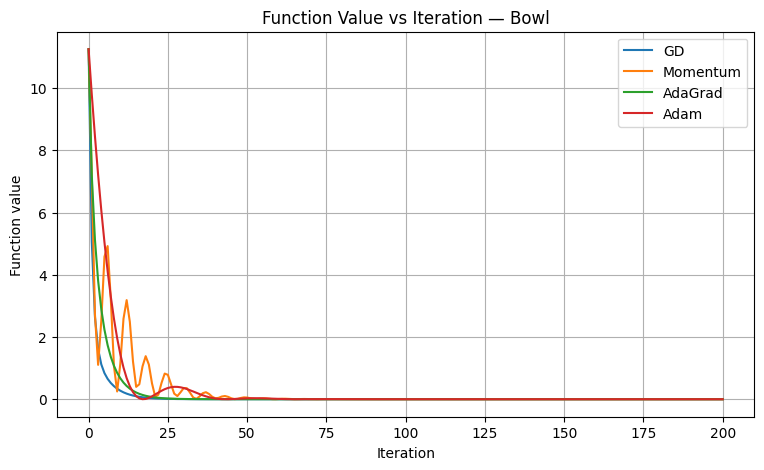

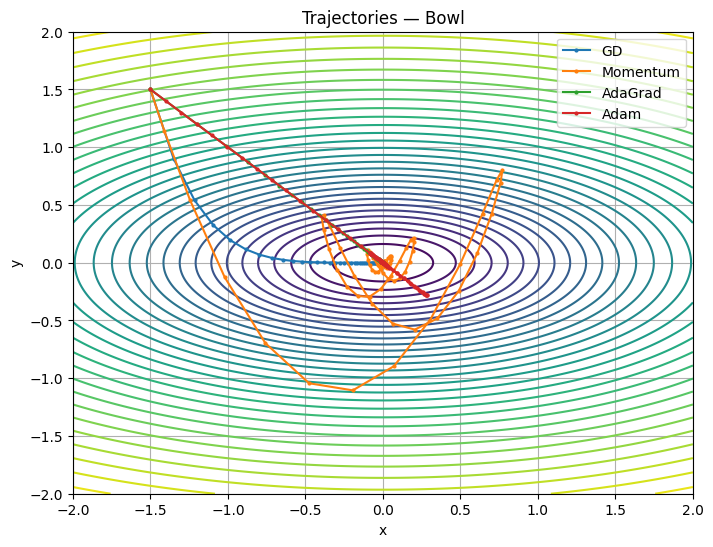

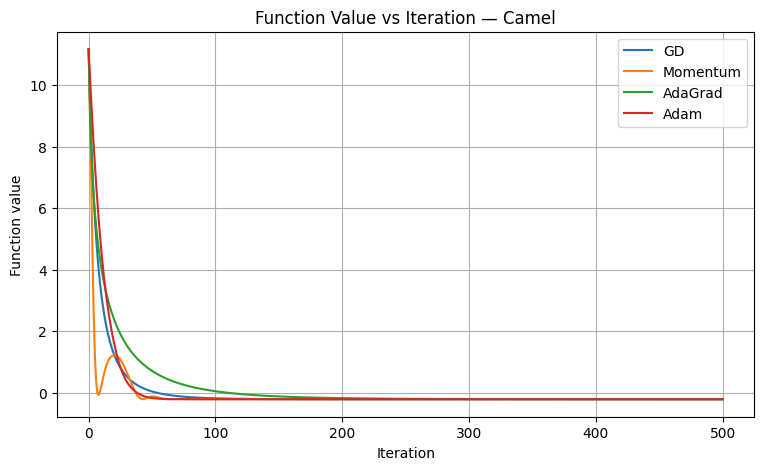

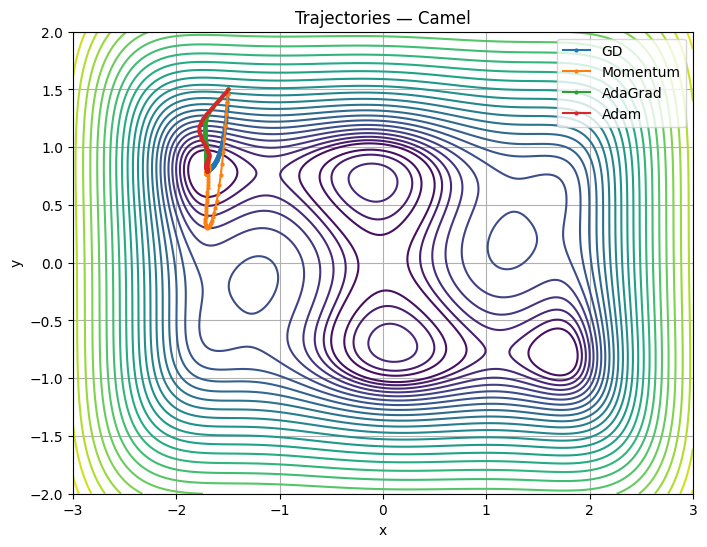

In [80]:
plot_values(results_bowl, "Function Value vs Iteration — Bowl")
plot_trajectories_contour(bowl, results_bowl, xlim=(-2, 2), ylim=(-2, 2), title="Trajectories — Bowl")

plot_values(results_camel, "Function Value vs Iteration — Camel")
plot_trajectories_contour(camel, results_camel, xlim=(-3, 3), ylim=(-2, 2), title="Trajectories — Camel")

** TASK **
You might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

** ANSWER ** 
Removed the repeated optimizer loops by moving the common “initialize, compute gradient, update, record history” flow into one base optimizer class and letting each optimizer implement only its own update logic.

** TASK **
**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same Hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

** ANSWER **

On the convex bowl, all four optimizers move toward the minimum, but AdaGrad and plain Gradient Descent show the cleanest and most stable behavior with the chosen hyperparameters. AdaGrad reaches the minimum quickly while keeping the trajectory smooth, and Gradient Descent is also stable, although less aggressive. Momentum converges as well, but its path is visibly more oscillatory, which suggests that the momentum term can overshoot on a simple convex surface when the settings are not perfectly tuned. Adam is also fast, but on this easy objective it does not clearly outperform the simpler stable methods.

On the Camel function, Adam performs best in this particular run because it reaches a lower function value faster and settles more effectively than the other methods. However, Camel is non-convex and contains multiple basins, so these plots are not enough to claim that any optimizer will reliably find the global minimum from arbitrary starting points; the final basin can depend on initialization. The same hyperparameters therefore do not work equally well on both functions: the bowl is forgiving, while Camel is much more sensitive to step size and update dynamics. Compared with plain Gradient Descent, Momentum can accelerate movement along shallow directions but may oscillate, AdaGrad automatically rescales updates and gives very stable progress, and Adam combines momentum with adaptive step sizing, which is why it looks strongest on the harder landscape here.

# Bonus. An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent

The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\mbox{ if $w_i > 0$},\\
+\alpha\lambda,\mbox{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\mbox{ if $w_i \geqslant \alpha\lambda$},\\
0,\mbox{ if $|w_i| > \alpha\lambda$},\\
w_i + \alpha\lambda,\mbox{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$

In [81]:
# FAST DEBUG SWITCHES
DEBUG_EPOCHS = 3
DEBUG_STEPS = 100

print("Use DEBUG_EPOCHS and DEBUG_STEPS manually in experiment cells if needed.")

Use DEBUG_EPOCHS and DEBUG_STEPS manually in experiment cells if needed.
